In [1]:
!gdown 1XNQvD8RtK49KNIR7VK9nkmb6tTPNXwVu


/Users/nithinys/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1XNQvD8RtK49KNIR7VK9nkmb6tTPNXwVu
To: /Users/nithinys/GithubRepos/ml-ai-genai-ds-journal/module05-unsupervised/kmeans+++/Cust_Spend_Data.csv
100%|███████████████████████████████████████████| 266/266 [00:00<00:00, 659kB/s]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns

%matplotlib inline

In [3]:
custData = pd.read_csv("Cust_Spend_Data.csv")
custData.head(10)

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1,A,10000,2,1,1,0
1,2,B,7000,3,0,10,9
2,3,C,7000,7,1,3,4
3,4,D,6500,5,1,1,4
4,5,E,6000,6,0,12,3
5,6,F,4000,3,0,1,8
6,7,G,2500,5,0,11,2
7,8,H,2500,3,0,1,1
8,9,I,2000,2,0,2,2
9,10,J,1000,4,0,1,7


In [4]:
custDataAttr=custData.iloc[:,2:]
custDataAttr.head()

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,10000,2,1,1,0
1,7000,3,0,10,9
2,7000,7,1,3,4
3,6500,5,1,1,4
4,6000,6,0,12,3


In [5]:
custDataScaled=custDataAttr.apply(zscore)
custDataScaled.head(10)

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1.886498,-1.240347,1.527525,-0.741433,-1.380131
1,0.787567,-0.620174,-0.654654,1.280656,1.725164
2,0.787567,1.860521,1.527525,-0.292080,0.000000
3,0.604412,0.620174,1.527525,-0.741433,0.000000
4,0.421257,1.240347,-0.654654,1.730009,-0.345033
5,-0.311364,-0.620174,-0.654654,-0.741433,1.380131
6,-0.860829,0.620174,-0.654654,1.505333,-0.690066
7,-0.860829,-0.620174,-0.654654,-0.741433,-1.035098
8,-1.043984,-1.240347,-0.654654,-0.516756,-0.690066
9,-1.410294,0.000000,-0.654654,-0.741433,1.035098


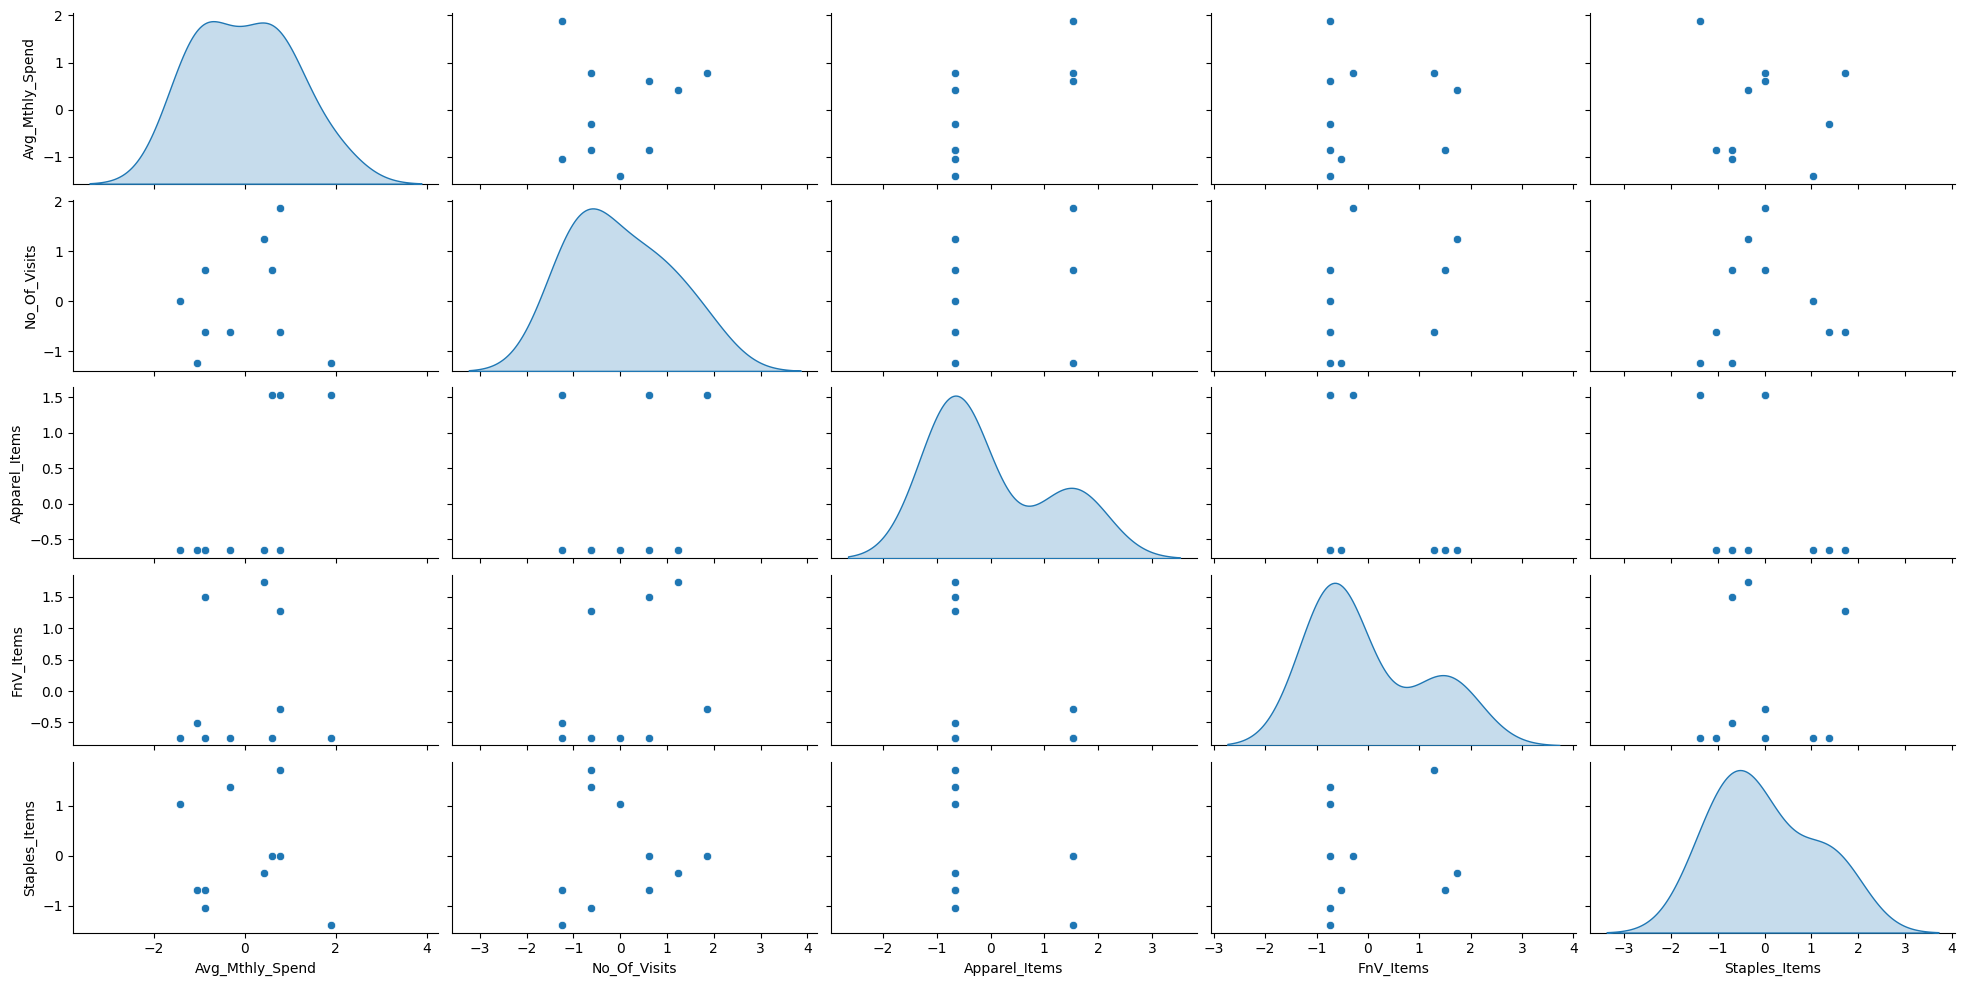

In [6]:
sns.pairplot(custDataScaled, height=2,aspect=2 , diag_kind='kde')

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [8]:
Z = linkage(custDataScaled, metric='euclidean', method='average')

In [9]:
Z.shape

(9, 4)

In [10]:
Z

array([[ 7.        ,  8.        ,  0.76660834,  2.        ],
       [ 5.        ,  9.        ,  1.30817103,  2.        ],
       [ 2.        ,  3.        ,  1.33188797,  2.        ],
       [ 4.        ,  6.        ,  1.48252699,  2.        ],
       [10.        , 11.        ,  2.29187962,  4.        ],
       [ 1.        , 13.        ,  3.01368978,  3.        ],
       [ 0.        , 12.        ,  3.12171991,  3.        ],
       [14.        , 15.        ,  3.23053961,  7.        ],
       [16.        , 17.        ,  3.78685213, 10.        ]])

Text(0.5, 1.0, 'Dendogram using Average linkage')

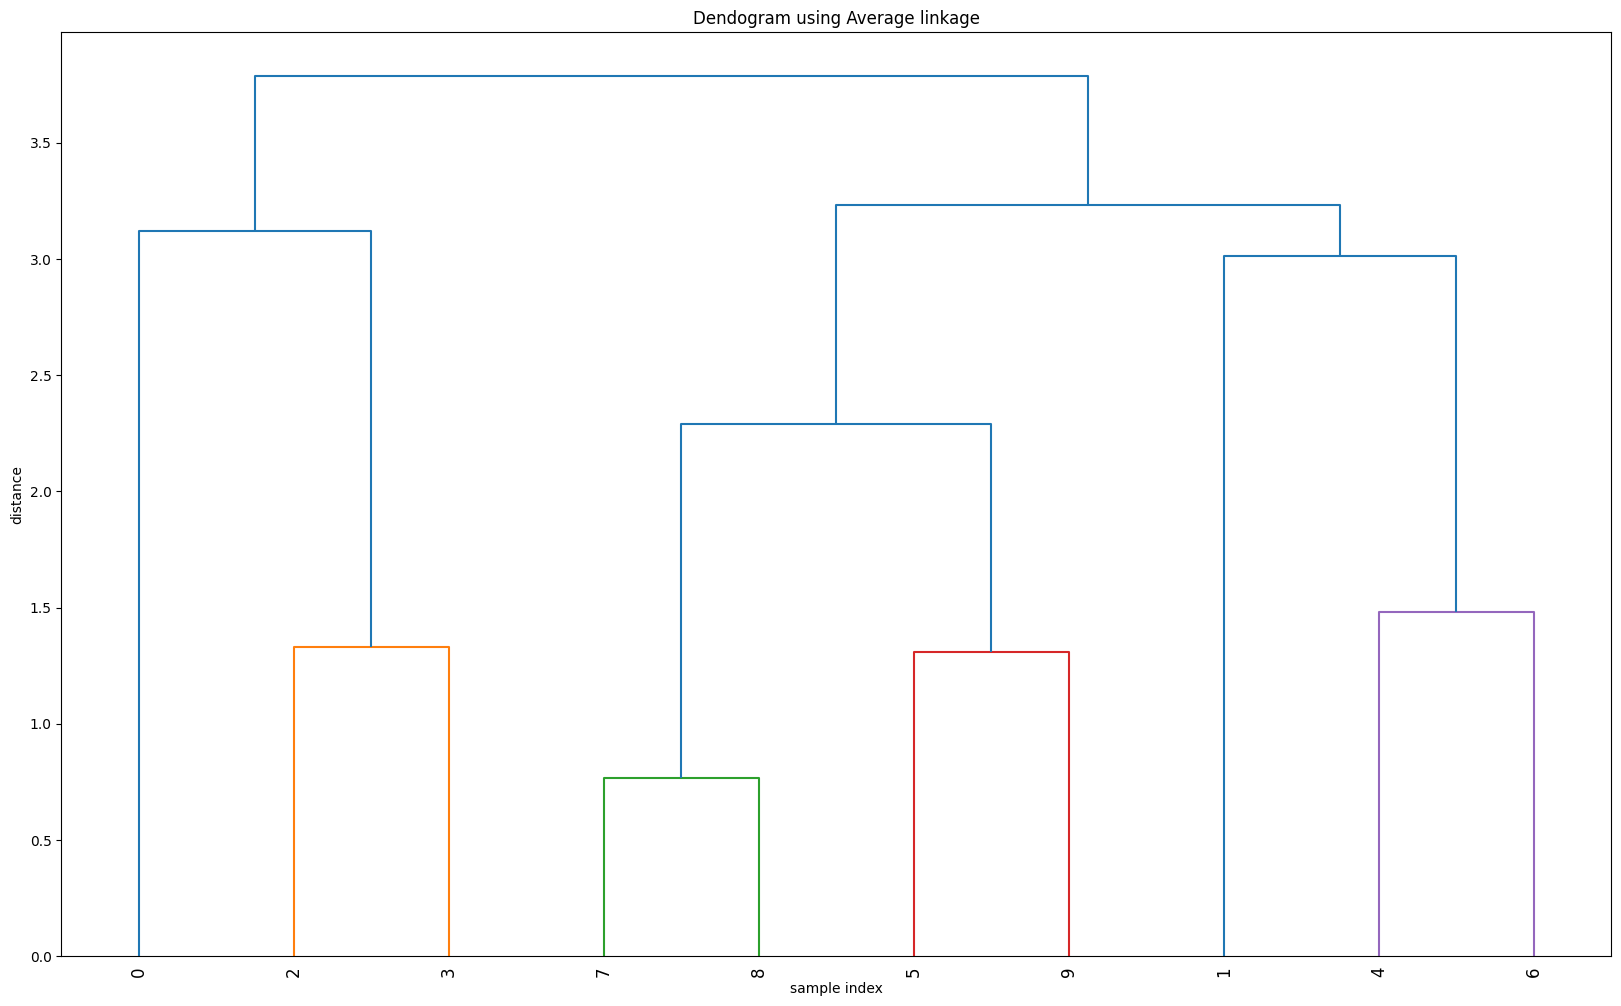

In [11]:
fig, ax = plt.subplots(figsize=(20, 12))
dendrogram(Z, labels=custDataScaled.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
ax.set_ylabel('distance')
ax.set_xlabel('sample index')
ax.set_title("Dendogram using Average linkage")

In [12]:
Z = linkage(custDataScaled, metric='euclidean', method='complete')

Text(0.5, 1.0, 'Dendogram using Complete linkage')

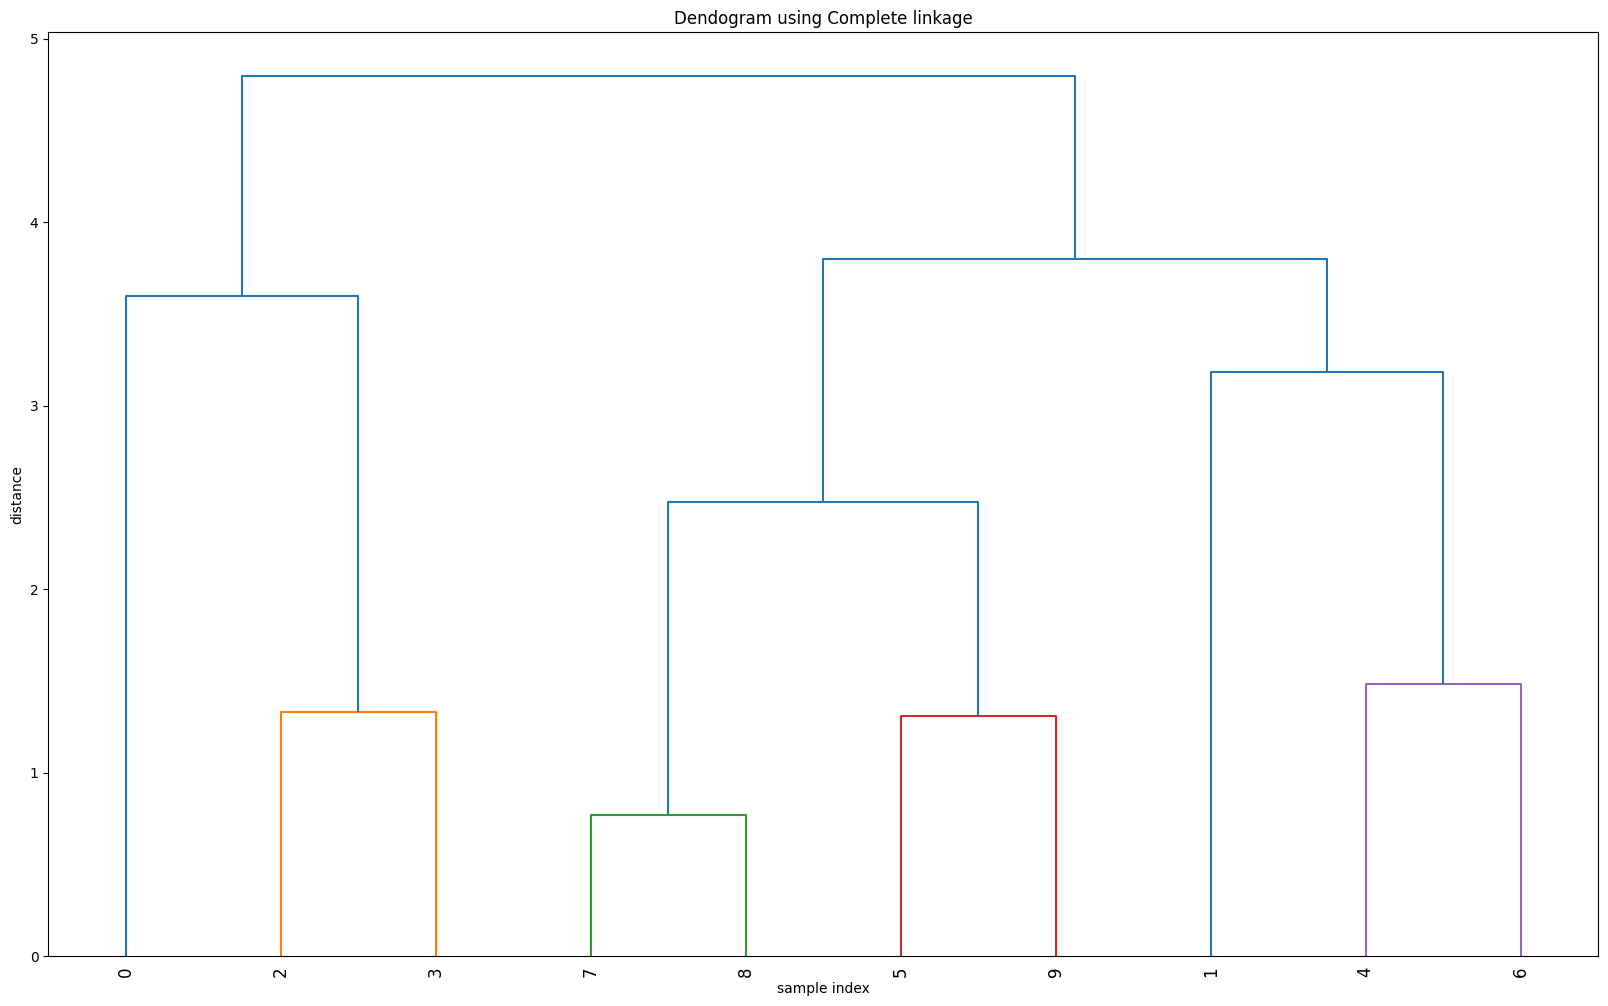

In [13]:
fig, ax = plt.subplots(figsize=(20, 12))
dendrogram(Z, labels=custDataScaled.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
ax.set_ylabel('distance')
ax.set_xlabel('sample index')
ax.set_title("Dendogram using Complete linkage")

In [14]:
Z = linkage(custDataScaled, metric='euclidean', method='ward')

Text(0.5, 1.0, 'Dendogram using Ward linkage')

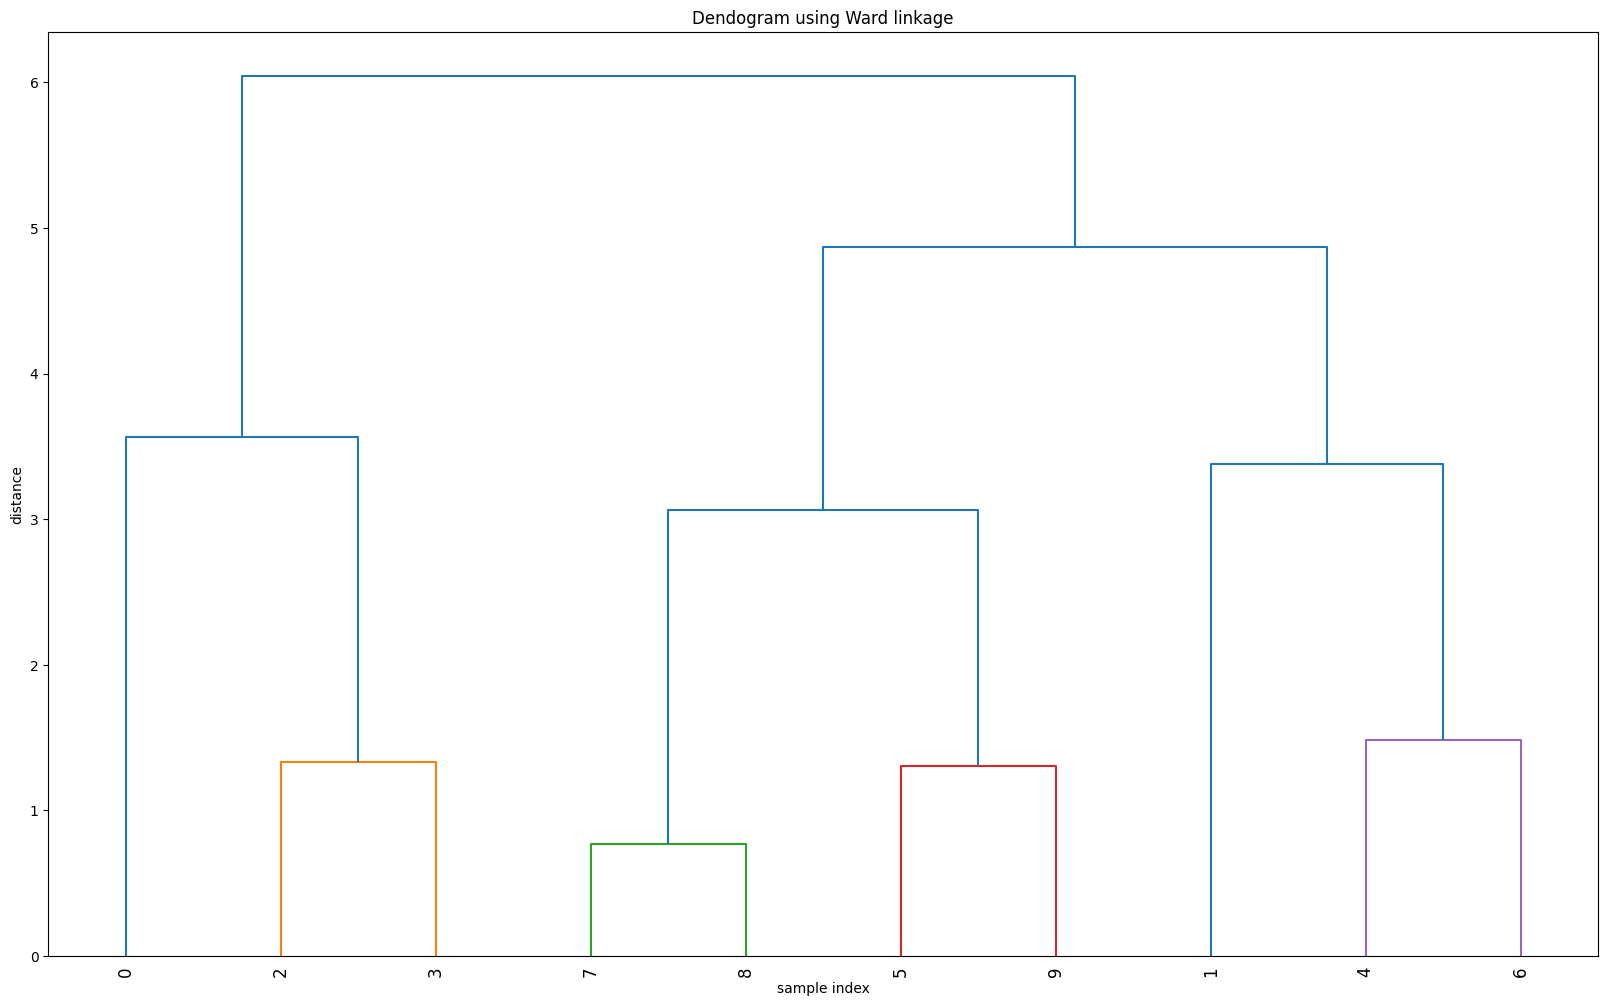

In [15]:
fig, ax = plt.subplots(figsize=(20, 12))
dendrogram(Z, labels=custDataScaled.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
ax.set_ylabel('distance')
ax.set_xlabel('sample index')
ax.set_title("Dendogram using Ward linkage")

Text(0, 0.5, 'distance')

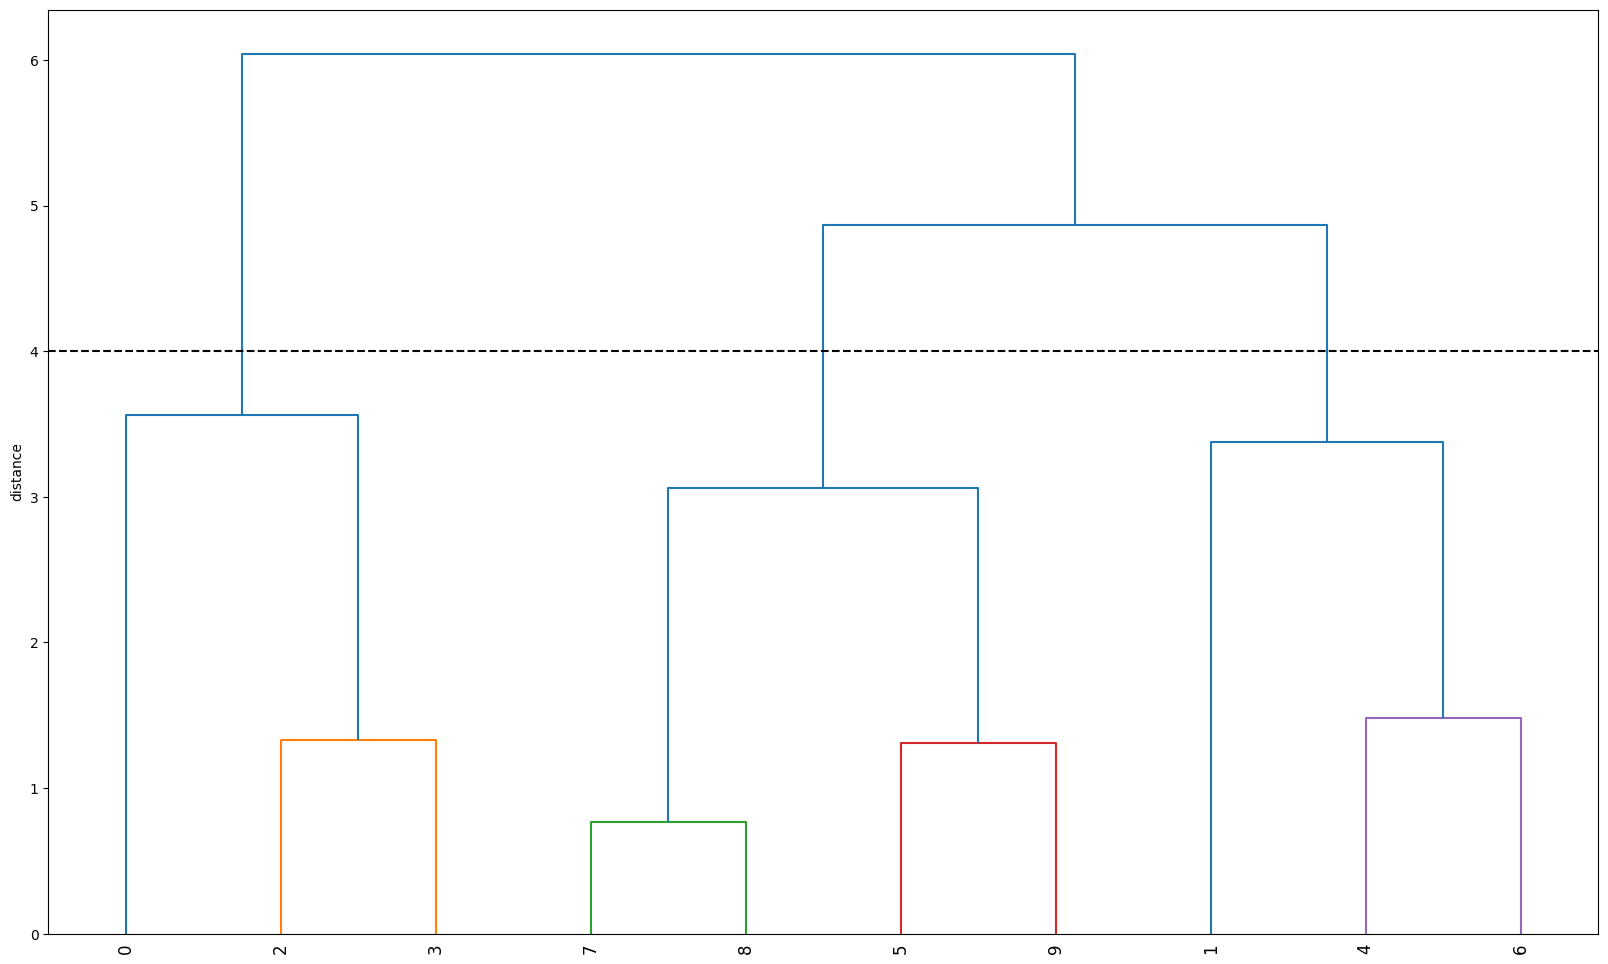

In [16]:
fig, ax = plt.subplots(figsize=(20, 12))
dendrogram(Z, labels=custDataScaled.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
plt.axhline(y=4, color='k', linestyle='--')
ax.set_ylabel('distance')

In [17]:
from sklearn.cluster import AgglomerativeClustering

In [21]:
# ...existing code...
model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
# ...existing code...

In [22]:
model.fit(custDataScaled)

AgglomerativeClustering(n_clusters=3)

In [23]:
custDataAttr['labels'] = model.labels_
custDataAttr.head(10)

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,labels
0,10000,2,1,1,0,0
1,7000,3,0,10,9,1
2,7000,7,1,3,4,0
3,6500,5,1,1,4,0
4,6000,6,0,12,3,1
5,4000,3,0,1,8,2
6,2500,5,0,11,2,1
7,2500,3,0,1,1,2
8,2000,2,0,2,2,2
9,1000,4,0,1,7,2


In [24]:
# analysis of clusters formed
h_clusters_mthly_spend = 	pd.DataFrame(custDataAttr.groupby(["labels"]).Avg_Mthly_Spend.mean())
h_clusters_num_of_visits = 	pd.DataFrame(custDataAttr.groupby(["labels"]).No_Of_Visits.mean())
h_clusters_apparel_items = 	pd.DataFrame(custDataAttr.groupby(["labels"]).Apparel_Items.mean())
h_clusters_fnv_items = 	pd.DataFrame(custDataAttr.groupby(["labels"]).FnV_Items.mean())
h_clusters_staples_items = 	pd.DataFrame(custDataAttr.groupby(["labels"]).Staples_Items.mean())

In [25]:
df = pd.concat([pd.Series([0,1,2]), h_clusters_mthly_spend, h_clusters_num_of_visits, h_clusters_apparel_items,h_clusters_fnv_items, h_clusters_staples_items ], axis=1)
df.columns = ["Cluster_id","Avg_Mthly_Spend","No_Of_Visits" ,"Apparel_Items", "FnV_Items", "Staples_Items"]
df.head()

,Cluster_id,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,0,7833.333333,4.666667,1.0,1.666667,2.666667
1,1,5166.666667,4.666667,0.0,11.000000,4.666667
2,2,2375.000000,3.000000,0.0,1.250000,4.500000


<Axes: xlabel='Cluster_id', ylabel='Avg_Mthly_Spend'>

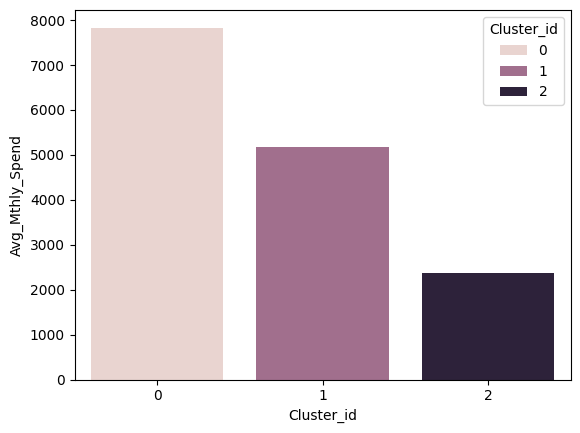

In [26]:
sns.barplot(x=df.Cluster_id, y=df.Avg_Mthly_Spend, hue=df.Cluster_id)

<Axes: xlabel='Cluster_id', ylabel='No_Of_Visits'>

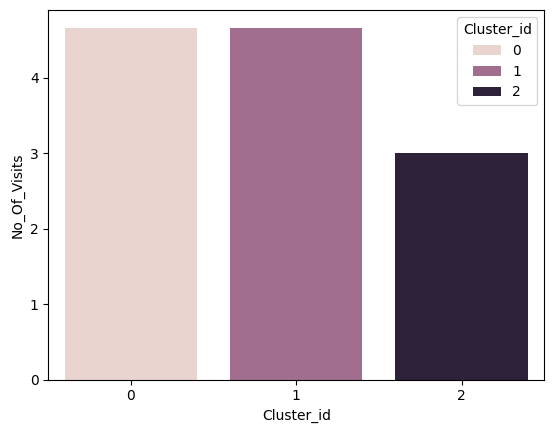

In [27]:
sns.barplot(x=df.Cluster_id, y=df.No_Of_Visits, hue=df.Cluster_id)